In [1]:
import os 
import sys
sys.path.append('./')
sys.path.append("../")

import torch
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from vi_rnn.utils import *
from vi_rnn.load_data import * 
from vi_rnn.evaluation import * 
from vi_rnn.saving import load_model
from vi_rnn.generate import * 

import pickle
import pandas as pd 

from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

import warnings
warnings.filterwarnings("ignore")
torch.set_warn_always(False)

torch.manual_seed(0)
np.random.seed(0)

%matplotlib inline
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = False

In [2]:
stat_dir=  "../results/model_evals/"

In [3]:
def load_stats(model_configs, eval_dataset='nk341_mPFC'):
    kl_divs = {c["name"]: [] for c in model_configs}
    sliced_was_dists = {c["name"]: [] for c in model_configs}
    was_dists = {c["name"]: [] for c in model_configs}
    mres = {c["name"]: [] for c in model_configs}

    airpuff_r_means = {c["name"]: [] for c in model_configs}
    airpuff_r_stds = {c["name"]: [] for c in model_configs}
    reward_r_means = {c["name"]: [] for c in model_configs}
    reward_r_stds = {c["name"]: [] for c in model_configs}


    for i, c in enumerate(model_configs): 
        # stat_dict_path = f'{eval_dataset}_{c["neuromodulation"]}_rank_{c["rank"]}_activation_{c["activation"]}_seed_{seed}_stim_{c["stim"]}_binsize_{str(c["bin_size"]).replace(".", "_")}_daleslaw_{c["dales_law"]}/stat_dict.pkl'
        stat_dict_path = f'{eval_dataset}_{c["neuromodulation"]}_rank_{c["rank"]}_activation_{c["activation"]}_seed_{c["seed"]}_stim_{c["stim"]}_binsize_{str(c["bin_size"]).replace(".", "_")}_daleslaw_{c["dales_law"]}_obs_{c["obs"]}_shift_{c["shift"]}/stat_dict.pkl'
        
        file_path = os.path.join(stat_dir, stat_dict_path)
        with open(file_path, 'rb') as f: 
            stat_dict = pickle.load(f)
            kl_divs[c["name"]].append(np.median(stat_dict['kl divs']))
            # kl_divs[c["name"]] += stat_dict['kl divs']
            sliced_was_dists[c["name"]].append(np.median(stat_dict['sliced wasserstein']))
            was_dists[c["name"]].append(np.median(stat_dict['wasserstein']))

            mres[c["name"]].append(np.mean(stat_dict['mres']))
            
            airpuff_r_means[c["name"]].append(np.median(stat_dict['R airpuff mean']))
            airpuff_r_stds[c["name"]].append(np.median(stat_dict['R airpuff std']))

            reward_r_means[c["name"]].append(np.median(stat_dict['R reward mean']))
            reward_r_stds[c["name"]].append(np.median(stat_dict['R reward std']))

    # append data stats 
    # kl_divs['data'] = kl_divs_data
    # was_dists['data'] = was_dists_data
    # mres['data'] = mres_data          
    return kl_divs, was_dists, sliced_was_dists, mres, airpuff_r_means, airpuff_r_stds, reward_r_means, reward_r_stds

In [4]:
seeds = [948, 9157, 9974, 8228, 1625, 4385, 4191, 3142, 4486, 4015, 343, 5047, 4244, 6508, 3433, 760, 6572, 7014, 159, 235, 4739]
model_configs = [
    {
        "name": "postsynaptic",
        "neuromodulation": "postsynaptic", 
        "stim": True, 
        "rank": 2, 
        "dales_law": False,
        "activation": "relu", 
        "bin_size": 0.05, 
        "obs": 'poisson', 
        "shift": shift,
        "seed": seeds[i]
    } for i, shift in enumerate(range(-10, 10))
]

In [5]:
res = load_stats(model_configs, 'nk339_mPFC')

In [6]:
airpuff_r_means, airpuff_r_stds = res[-4], res[-3]
reward_r_means, reward_r_stds = res[-2], res[-1]

# compute standard error
airpuff_r_stderrs = np.array(airpuff_r_stds['postsynaptic']) / np.sqrt(184)
reward_r_stderrs = np.array(reward_r_stds['postsynaptic']) / np.sqrt(184)

Text(0, 0.5, 'R')

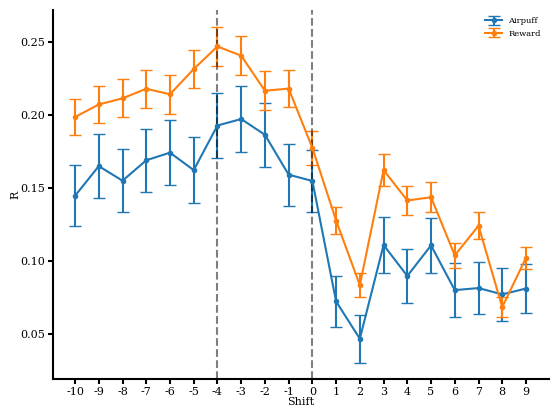

In [7]:
plt.errorbar(np.arange(-10, 10), airpuff_r_means['postsynaptic'], yerr=airpuff_r_stderrs, fmt='-o', capsize=4, label='Airpuff')      # little caps at the end of error bars
plt.errorbar(np.arange(-10, 10), reward_r_means['postsynaptic'], yerr=reward_r_stderrs, fmt='-o', capsize=4, label='Reward')      # little caps at the end of error bars

# plt.plot(np.arange(-10, 10), airpuff_r_means['postsynaptic'], label='Airpuff trials')
# plt.plot(np.arange(-10, 10), reward_r_means['postsynaptic'], label='Reward Trials')
plt.xticks(np.arange(-10, 10), np.arange(-10, 10))
plt.axvline(0, linestyle='--', c='black', alpha=0.5)
plt.axvline(-4, linestyle='--', c='black', alpha=0.5)
plt.legend()
plt.xlabel('Shift')
plt.ylabel('R')